In [1]:
from astropy.table import Table
from astropy.time import Time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask.dataframe as dd
import sqlite3 

roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
filenames = ['Entries_UVOT_csv','Entries_OM_csv']
projects = ['Swift-UVOT', 'XMM-Newton']

In [3]:
filename = filenames[0]
project = projects[0]
filepath = roots_tfm + '/'+project+'/'+filename

In [4]:
dat = dd.read_csv(filepath)

In [5]:
dat.dtypes

SRCNUM                         int64
UVW2_FLUX                    float64
UVW2_FLUX_ERR                float64
UVM2_FLUX                    float64
UVM2_FLUX_ERR                float64
UVW1_FLUX                    float64
UVW1_FLUX_ERR                float64
U_FLUX                       float64
U_FLUX_ERR                   float64
B_FLUX                       float64
B_FLUX_ERR                   float64
V_FLUX                       float64
V_FLUX_ERR                   float64
UVW2_QUALITY_FLAG            float64
UVM2_QUALITY_FLAG            float64
UVW1_QUALITY_FLAG            float64
U_QUALITY_FLAG               float64
B_QUALITY_FLAG               float64
V_QUALITY_FLAG               float64
UVW2_EXTENDED        string[pyarrow]
UVM2_EXTENDED        string[pyarrow]
UVW1_EXTENDED        string[pyarrow]
U_EXTENDED           string[pyarrow]
B_EXTENDED           string[pyarrow]
V_EXTENDED           string[pyarrow]
MJD_START                    float64
dtype: object

In [6]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,0.0,<NA>,<NA>,<NA>,False,False,False,55460.217431
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0.0,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55460.281007
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0.0,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55468.007523


In [7]:
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["True","False"], ordered=False)

In [8]:
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="temp")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="temp")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="temp")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="temp")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="temp")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="temp")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']=="False","True")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']=="False","True")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']=="False","True")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']=="False","True")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']=="False","True")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']=="False","True")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']=="temp","False")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']=="temp","False")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']=="temp","False")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']=="temp","False")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']=="temp","False")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']=="temp","False")

In [9]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,999.0,True,True,False,False,False,False,54973.746285
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,999.0,True,True,False,False,False,False,54973.746285
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,0.0,False,False,False,True,True,True,55460.217431
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0.0,999.0,999.0,False,False,False,True,False,False,55460.281007
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0.0,999.0,999.0,False,False,False,True,False,False,55468.007523


In [10]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'MJD_START': np.int32})

In [11]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,True,True,False,False,False,False,54973
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,True,True,False,False,False,False,54973
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,0,False,False,False,True,True,True,55460
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0,999,999,False,False,False,True,False,False,55460
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0,999,999,False,False,False,True,False,False,55468


In [12]:
#values = []
#for j in range(dat.npartitions):
#    print("Computing partition " + str(j+1) + " over " + str(dat.npartitions) + ".")
#    values.extend(np.array(Time(list(dat.partitions[j].compute().loc[:,'DATE_MIN']),format='fits', scale='utc').mjd).astype(int).tolist())

In [13]:
dat.dtypes

SRCNUM                  int32
UVW2_FLUX             float32
UVW2_FLUX_ERR         float32
UVM2_FLUX             float32
UVM2_FLUX_ERR         float32
UVW1_FLUX             float32
UVW1_FLUX_ERR         float32
U_FLUX                float32
U_FLUX_ERR            float32
B_FLUX                float32
B_FLUX_ERR            float32
V_FLUX                float32
V_FLUX_ERR            float32
UVW2_QUALITY_FLAG      uint16
UVM2_QUALITY_FLAG      uint16
UVW1_QUALITY_FLAG      uint16
U_QUALITY_FLAG         uint16
B_QUALITY_FLAG         uint16
V_QUALITY_FLAG         uint16
UVW2_EXTENDED        category
UVM2_EXTENDED        category
UVW1_EXTENDED        category
U_EXTENDED           category
B_EXTENDED           category
V_EXTENDED           category
MJD_START               int32
dtype: object

In [14]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,True,True,False,False,False,False,54973
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,True,True,False,False,False,False,54973
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,0,False,False,False,True,True,True,55460
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0,999,999,False,False,False,True,False,False,55460
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0,999,999,False,False,False,True,False,False,55468


In [15]:
#dat.to_parquet(roots_tfm + '/'+project+'/'+'Entries_UVOT_parquet')

In [16]:
df_match = Table.read( roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om').to_pandas()
df_match.head()

,SRCNUM_1,RA_1,DEC_1,POSERR_1,COUNT_1,SRCNUM_2,RA_2,DEC_2,POSERR_2,COUNT_2,Separation,angDist
0,5,0.000172,8.371812,0.579813,1,1,0.000160,8.371681,0.273446,1,0.185867,0.475779
1,66,0.004279,8.249917,0.736678,1,10,0.004393,8.250327,0.318405,1,0.484476,1.533487
2,102,0.005933,8.163762,0.709919,1,11,0.005988,8.163922,0.317418,1,0.197048,0.607305
3,182,0.010155,8.307648,0.663965,1,20,0.010337,8.307771,0.316142,1,0.267008,0.785089
4,494,0.026486,8.306166,0.719527,1,64,0.026368,8.306161,0.307228,1,0.136319,0.419898


In [17]:
df_match = df_match.drop(columns=['RA_1','DEC_1','POSERR_1','COUNT_1','RA_2','DEC_2','POSERR_2','COUNT_2','Separation','angDist'])

In [18]:
dat_UVOT_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_2'])].compute()
dat_UVOT_match.shape

(3124972, 26)

In [19]:
df_source = pd.read_csv(roots_tfm + '/SOURCE_complete_galaxies.csv')
dat_UVOT = dat[dat['SRCNUM'].isin(df_source['SRCNUM_2'])].compute()
dat_UVOT.shape

(737671, 26)

In [20]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
#dat_UVOT.to_sql("Entries_UVOT", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

In [21]:
#dat_UVOT.to_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv',index=True)

In [22]:
filename = filenames[1]
project = projects[1]
filepath = roots_tfm + '/'+project+'/'+filename

In [23]:
dat = dd.read_csv(filepath)

In [24]:
dat.dtypes

SRCNUM                  int64
UVW2_AB_FLUX          float64
UVW2_AB_FLUX_ERR      float64
UVM2_AB_FLUX          float64
UVM2_AB_FLUX_ERR      float64
UVW1_AB_FLUX          float64
UVW1_AB_FLUX_ERR      float64
U_AB_FLUX             float64
U_AB_FLUX_ERR         float64
B_AB_FLUX             float64
B_AB_FLUX_ERR         float64
V_AB_FLUX             float64
V_AB_FLUX_ERR         float64
UVW2_QUALITY_FLAG     float64
UVM2_QUALITY_FLAG     float64
UVW1_QUALITY_FLAG     float64
U_QUALITY_FLAG        float64
B_QUALITY_FLAG        float64
V_QUALITY_FLAG        float64
UVW2_EXTENDED_FLAG    float64
UVM2_EXTENDED_FLAG    float64
UVW1_EXTENDED_FLAG    float64
U_EXTENDED_FLAG       float64
B_EXTENDED_FLAG       float64
V_EXTENDED_FLAG       float64
MJD_START             float64
dtype: object

In [25]:
dat = dat.rename(columns={'UVW2_AB_FLUX':'UVW2_FLUX','UVW1_AB_FLUX': 'UVW1_FLUX','UVM2_AB_FLUX':'UVM2_FLUX', 'U_AB_FLUX':'U_FLUX',\
                    'V_AB_FLUX':'V_FLUX', 'B_AB_FLUX':'B_FLUX', 'UVW2_AB_FLUX_ERR':'UVW2_FLUX_ERR','UVW1_AB_FLUX_ERR': 'UVW1_FLUX_ERR', \
                    'UVM2_AB_FLUX_ERR':'UVM2_FLUX_ERR', 'U_AB_FLUX_ERR':'U_FLUX_ERR','V_AB_FLUX_ERR':'V_FLUX_ERR', \
                    'B_AB_FLUX_ERR':'B_FLUX_ERR', 'MJD_START' : 'MJD','UVW2_EXTENDED_FLAG' : 'UVW2_EXTENDED', \
                    'UVM2_EXTENDED_FLAG' : 'UVM2_EXTENDED','UVW1_EXTENDED_FLAG' : 'UVW1_EXTENDED','U_EXTENDED_FLAG' : 'U_EXTENDED', \
                    'B_EXTENDED_FLAG' : 'B_EXTENDED', 'V_EXTENDED_FLAG' : 'V_EXTENDED'})

In [26]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,58972.664606
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,NaN,130.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,54134.548438
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,56291.869572
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,NaN,2.0,2.0,NaN,NaN,NaN,NaN,0.0,0.0,56291.869572
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,56086.733368


In [27]:
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']==0,"True")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']==0,"True")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']==0,"True")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']==0,"True")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']==0,"True")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']==0,"True")

In [28]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0.0,999.0,999.0,NaN,NaN,NaN,True,NaN,NaN,58972.664606
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,999.0,130.0,999.0,NaN,NaN,NaN,NaN,True,NaN,54134.548438
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,999.0,2.0,999.0,NaN,NaN,NaN,NaN,True,NaN,56291.869572
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,999.0,2.0,2.0,NaN,NaN,NaN,NaN,True,True,56291.869572
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0.0,999.0,999.0,NaN,NaN,True,True,NaN,NaN,56086.733368


In [29]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'MJD': np.int32, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type})

In [30]:
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="False")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="False")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="False")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="False")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="False")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="False")

In [31]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0,999,999,False,False,False,True,False,False,58972
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,999,130,999,False,False,False,False,True,False,54134
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,999,2,999,False,False,False,False,True,False,56291
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,999,2,2,False,False,False,False,True,True,56291
4,4,NaN,NaN,NaN,NaN,1.674827e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0,999,999,False,False,True,True,False,False,56086


In [32]:
#dat.to_parquet(roots_tfm + '/'+project+'/'+'Entries_OM_parquet')

In [33]:
dat_OM_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_1'])].compute()
dat_OM_match.shape

(1646233, 26)

In [34]:
dat_OM = dat[dat['SRCNUM'].isin(df_source['SRCNUM_1'])].compute()
dat_OM.shape

(414357, 26)

In [35]:
dat_UVOT_match['U_EXTENDED'].unique()

['False', 'True']
Categories (2, object): ['True', 'False']

In [36]:
dat_OM_match['U_EXTENDED'].unique()

['False', 'True']
Categories (2, object): ['True', 'False']

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde

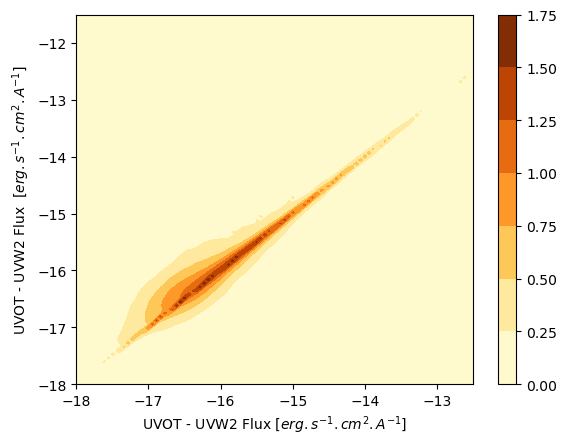

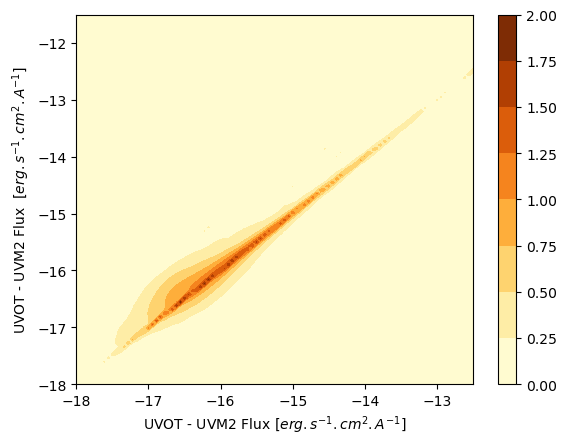

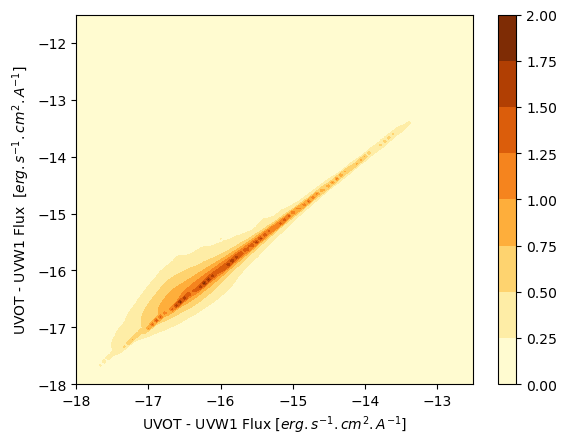

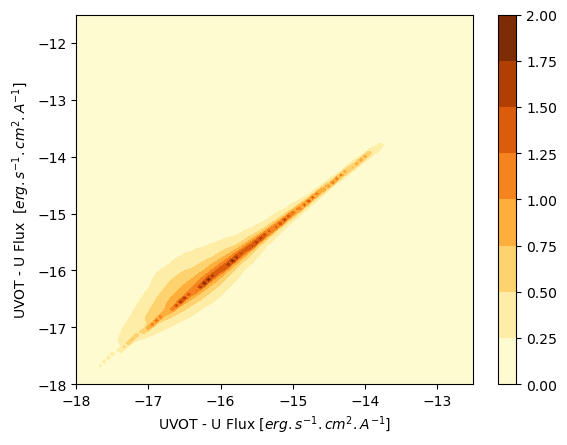

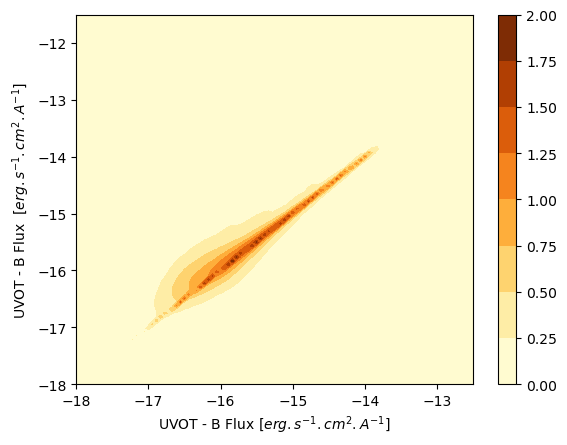

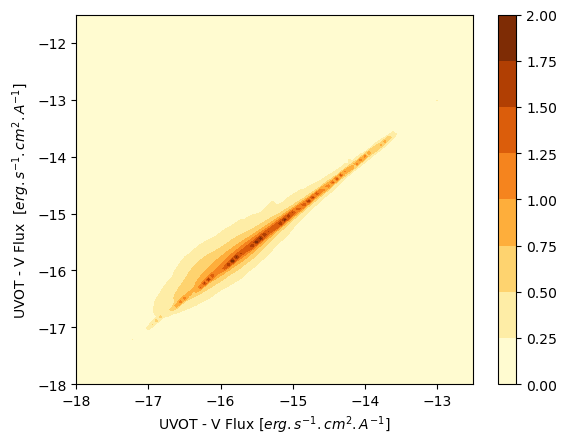

In [38]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT_match[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 

    # Dataframe UVOT best for this band
    df_flux_uvot_best = df_flux_uvot.loc[:,flux_name].copy()
    for name, group in df_flux_uvot.groupby('SRCNUM'):
        df_flux_uvot_best.loc[group.index.values] = df_flux_uvot.loc[group[flux_err].idxmin(),flux_name]

    # Plot figure
    fig, ax =plt.subplots()
    ind_quality = (df_flux_uvot[flux_quality] == 0)
    data = np.vstack([np.log10(df_flux_uvot_best.loc[ind_quality]),np.log10(df_flux_uvot.loc[ind_quality,flux_name])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[-18:-12.5:100j, -18:-11.5:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)**(1/3)
    contour1 = ax.contourf(grid_x, grid_y, z, cmap='YlOrBr')
    cbar = plt.colorbar(contour1, ax=ax)

    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    fig.savefig(roots_tfm + '/Calibration/UVOT_vs_UVOT_ ' + flux + '_galaxies.png',dpi=1200)  

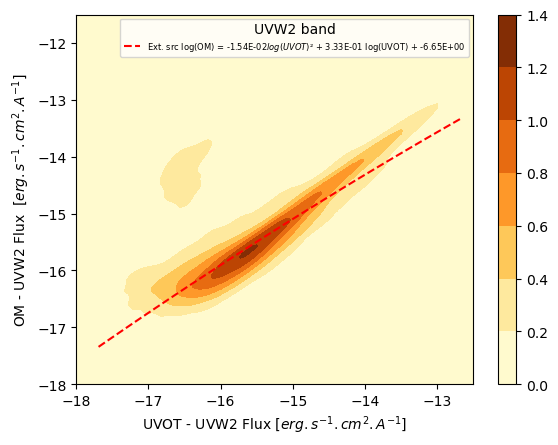

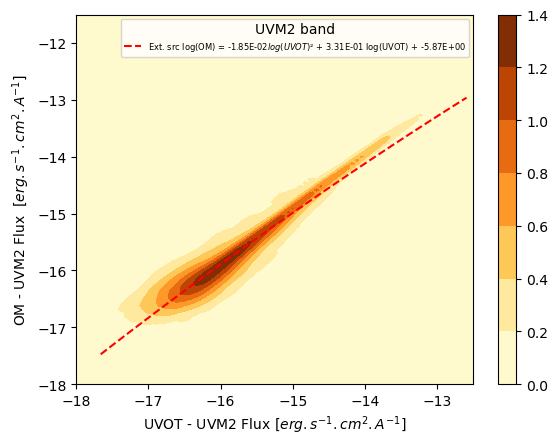

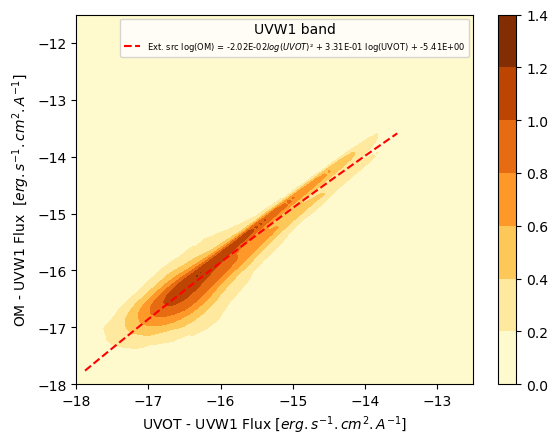

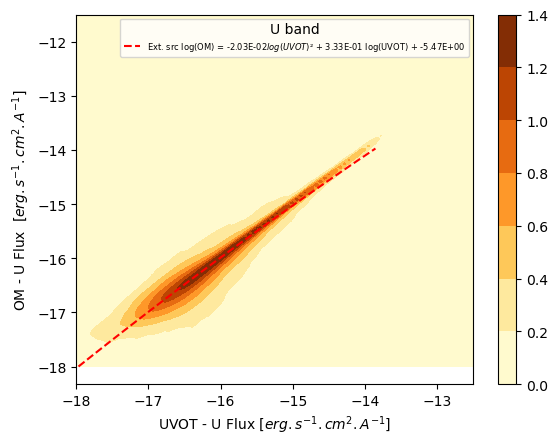

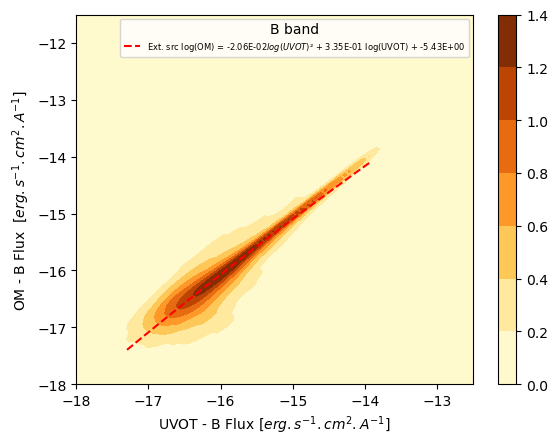

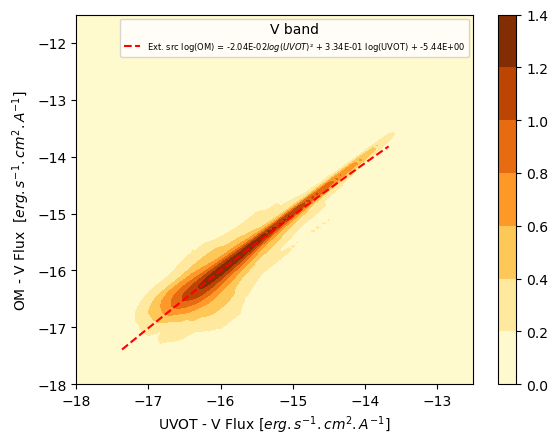

In [52]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT_match[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    ind_minflux = df_flux_uvot.groupby('SRCNUM').agg({flux_err : 'idxmin'})[flux_err]
    df_flux_uvot = df_flux_uvot.loc[ind_minflux,:].rename(columns={flux_name: flux_name + '_UVOT', \
                                                                   flux_err: flux_err + '_UVOT', \
                                                                   flag_extended: flag_extended  + '_UVOT',\
                                                                   flux_quality: flux_quality + '_UVOT',\
                                                                   'SRCNUM': 'SRCNUM_2'})

    # Data frame OM for this band
    df_flux_om = dat_OM_match[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()        
    ind_minflux = df_flux_om.groupby('SRCNUM').agg({flux_err : 'idxmin'})[flux_err]
    df_flux_om = df_flux_om.loc[ind_minflux,:].rename(columns={flux_name: flux_name + '_OM',\
                                                               flux_err: flux_err + '_OM', \
                                                               flag_extended: flag_extended  + '_OM',\
                                                               flux_quality: flux_quality + '_OM',\
                                                               'SRCNUM': 'SRCNUM_1'})

    # Merge results
    df_merge = df_match.merge(df_flux_uvot, on='SRCNUM_2').merge(df_flux_om, on='SRCNUM_1')

    # Plot figure
    fig, ax =plt.subplots()
    
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "True")
    ind_quality = (df_merge[flux_quality + '_UVOT'] == 0) & (df_merge[flux_quality + '_OM'] == 0)
    
    ind1 = ind_extended & ind_quality 
    #ax.scatter(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']), np.log10(df_merge.loc[ind1,flux_name + '_OM']), c='m',marker='x', \
    #           label='Ext. src')
    data = np.vstack([np.log10(df_merge.loc[ind_quality,flux_name + '_UVOT']),np.log10(df_merge.loc[ind_quality,flux_name + '_OM'])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[-18:-12.5:100j, -18:-11.5:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)**(1/3)
    contour1 = ax.contourf(grid_x, grid_y, z, cmap='YlOrBr')
    cbar = plt.colorbar(contour1, ax=ax)
    
    z2 = np.polyfit(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']),np.log10(df_merge.loc[ind1,flux_name + '_OM']), deg=2)
    p = np.poly1d(z2)
    xp = np.linspace(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']).min(), np.log10(df_merge.loc[ind1,flux_name + '_UVOT']).max(), 100)
    ax.plot(xp,p(xp), color='r', linestyle='dashed', label= "Ext. src log(OM) = " + 
              "{:.2E}".format(p[2]) + "$ log(UVOT)²$ + "+ "{:.2E}".format(p[1]) + " log(UVOT) + " + "{:.2E}".format(p[0]))

    ind_nan = dat_OM[flux_name].isna()
    #arr = np.array((p-dat_OM[(dat_OM[flag_extended]=="True") &  ~ind_nan][flux_name]).roots)
    #dat_OM[(dat_OM[flag_extended]=="True") &  ~ind_nan][flux_name] = [10**elem for elem in arr if ((elem>-18.5) and (elem<-12.5))]
    #arr = np.array((p-dat_OM_match[dat_OM_match[flag_extended]=="True"][flux_name]).roots)
    #dat_OM_match[dat_OM_match[flag_extended]=="True"][flux_name] = [10**elem for elem in arr if ((elem>-18.5) and (elem<-12.5))]

    ind2 = ~ind_extended & ind_quality
    #ax.scatter(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']), np.log10(df_merge.loc[ind2,flux_name + '_OM']), c='c',marker='x', \
    #           label='Not ext. src')
    if ind2.any():
        z2 = np.polyfit(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']),np.log10(df_merge.loc[ind2,flux_name + '_OM']), deg=2)
        p = np.poly1d(z2)
        xp = np.linspace(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']).min(), np.log10(df_merge.loc[ind2,flux_name + '_UVOT']).max(), 100)
        ax.plot(xp,p(xp), color='b', linestyle='dashed', label= "Not ext. src log(OM) = " + 
                  "{:.2E}".format(p[2]) + "$ log(UVOT)²$ + "+  "{:.2E}".format(p[1]) + " log(UVOT) + " + "{:.2E}".format(p[0]))
    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.legend(loc='upper right',prop={'size': 6},title= flux + " band")
    fig.savefig(roots_tfm + '/Calibration/UVOT_vs_OM_ ' + flux + '_galaxies_2.png',dpi=1200)  
    #arr = np.array((p-dat_OM[dat_OM[flag_extended]=="False" &  ~ind_nan][flux_name]).roots)
    #dat_OM[(dat_OM[flag_extended]=="False") &  ~ind_nan][flux_name] = [10**elem for elem in arr if ((elem>-18.5) and (elem<-12.5))]
    #arr = np.array((p-dat_OM_match[dat_OM_match[flag_extended]=="False"][flux_name]).roots)
    #dat_OM_match[dat_OM_match[flag_extended]=="False"][flux_name] = [10**elem for elem in arr if ((elem>-18.5) and (elem<-12.5))]

In [51]:
ind2.any()

np.False_

In [ ]:
df_merge.head()

In [ ]:
df_match.shape

In [ ]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT_match[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    ind_minflux = df_flux_uvot.groupby('SRCNUM').agg({flux_err : 'idxmin'})[flux_err]
    df_flux_uvot = df_flux_uvot.loc[ind_minflux,:].rename(columns={flux_name: flux_name + '_UVOT', \
                                                                   flux_err: flux_err + '_UVOT', \
                                                                   flag_extended: flag_extended  + '_UVOT',\
                                                                   flux_quality: flux_quality + '_UVOT',\
                                                                   'SRCNUM': 'SRCNUM_2'})

    # Data frame OM for this band
    df_flux_om = dat_OM_match[['SRCNUM',flux_name,flux_err]].dropna(subset=[flux_name]).reset_index() 
    ind_minflux = df_flux_om.groupby('SRCNUM').agg({flux_err : 'idxmin'})[flux_err]
    df_flux_om = df_flux_om.loc[ind_minflux,:].rename(columns={flux_name: flux_name + '_OM',\
                                                               flux_err: flux_err + '_OM', \
                                                               'SRCNUM': 'SRCNUM_1'})
    # Merge results
    df_merge = df_match.merge(df_flux_uvot, on='SRCNUM_2').merge(df_flux_om, on='SRCNUM_1')

    # Plot figure
    fig, ax =plt.subplots()
    
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "False")
    ind_quality = (df_merge[flux_quality + '_UVOT'] == 0)
    
    ind1 = ind_extended & ind_quality 
    ax.scatter(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']), np.log10(df_merge.loc[ind1,flux_name + '_OM']), c='m',marker='x', \
               label='Ext. src')
    z = np.polyfit(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']),np.log10(df_merge.loc[ind1,flux_name + '_OM']), deg=1)
    p = np.poly1d(z)
    xp = np.linspace(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']).min(), np.log10(df_merge.loc[ind1,flux_name + '_UVOT']).max(), 100)
    ax.plot(xp,p(xp), color='r', linestyle='dashed', label= "Ext. src log(OM) = " + 
              "{:.2E}".format(p[1]) + " log(UVOT) + " + "{:.2E}".format(p[0]))

    ind2 = ~ind_extended & ind_quality
    ax.scatter(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']), np.log10(df_merge.loc[ind2,flux_name + '_OM']), c='c',marker='x', \
               label='Not ext. src')
    z = np.polyfit(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']),np.log10(df_merge.loc[ind2,flux_name + '_OM']), deg=1)
    p = np.poly1d(z)
    xp = np.linspace(np.log10(df_merge.loc[ind2,flux_name + '_UVOT']).min(), np.log10(df_merge.loc[ind2,flux_name + '_UVOT']).max(), 100)
    ax.plot(xp,p(xp), color='b', linestyle='dashed', label= "Not ext. src log(OM) = " + 
              "{:.2E}".format(p[1]) + " log(UVOT) + " + "{:.2E}".format(p[0]))
    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.legend(loc='upper right',prop={'size': 8},title= flux + " band")

In [ ]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
dat_OM.to_sql("Entries_OM", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

In [ ]:
dat_OM.to_csv(roots_tfm + '/XMM-Newton/Entries_OM_galaxies.csv',index=True)